# Predicting the 2026-2027 Formula 1 Constructor Standings  
### PSTAT 131 Final Project  
### Brian Zeng // Perm Number: 7745235 // NetID: brianzeng  

![GettyImages-2247723919.jpg](media/GettyImages-2247723919.jpg "Ground-Effect Era Car - Kimi Antonelli, 2025 Las Vegas Grand Prix")

# Table of Contents

1. [Introduction](#introduction)
2. [Imports](#imports)
3. [Scraping Data](#scraping-data)
4. [Data Work](#data-work)
5. [Relationship Analysis](#relationship-analysis)
6. [Model Work](#model-work)
7. [Tuning Model](#tuning-model)
8. [Testing](#testing)
9. [Importance](#importance)
10. [Monte Carlo Simulation](#monte-carlo-simulation)
11. [Results](#results)
12. [Conclusion](#conclusion)
13. [Disclaimer](#disclaimer)
14. [Sources](#sources)
15. [Media](#media)

# Introduction
------------------------------------------

The new F1 season has finally arrived! If you're not familiar with F1, it is often referred to as the "pinnacle of motorsport", where teams recruit the fastest racers in the world to race with the fastest cars in the world. The championships aren't simply decided by whoever the fastest driver is, there are actually two championships: the driver's and constructor's. Every constructor must build their own cars within a window of rules and regulations for their drivers to race. With this new season comes major engine and aerodynamic regulation changes, not to mention new drivers and driver swaps. They aren't just small changes though, we are entering the era of a near 50/50 (previously 80/20) split of combustion and electric hybrid v-6 engines capable of ripping more than a thousand rear horsepower. In this project, we'll using the FastF1 python api to scrape race data dating back to the start of the 2010 season to train a machine learning model to predict the new pecking order of constructor standings for this upcoming season. 

# Imports
------------------------------------------

Before anything, we need all the necessary libraries to scrape, manage, train, and depict our data.  

fastf1: Gives us access to an F1 database with telemetry, timing, session results, etc. (Only using session results). 

pandas: Primarily for data manipulation, allowing us work with CSV files, clean and transform race results, aggregate race-level data into constructor-season statistics.  

numpy: For numerical operations such as calculating RMSE and MAE, and Monte Carlo simulations.  

matplotlib: For plotting and visualizing our data and results. Used to compare RMSE between ML models, championship probabilities, etc.  

seaborn: Used to create a heatmap to easily visualize our final results.  

scikit-learn: Added to tune and use regression models for prediction later on.  

time: To prevent rate-limiting while scraping data.  

pathlib: Used to save csv files during the scraping process.  

In [1]:
import fastf1
from pathlib import Path
import time

In [3]:
import matplotlib
matplotlib.use("Agg")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.ioff

<function matplotlib.pyplot.ioff() -> 'AbstractContextManager'>

In [4]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

import seaborn as sns

# Scraping Data
------------------------------------------
The database I was looking for isn't readily available on kaggle or other resources without lots of data manipulation. There are a few kaggle resources that were a part of what I wanted, but I didn't think it was worth it to piece together different databases and mess around with different variable names and formats and probably end up having to scrape what was missing anyways. The timeframe I wanted to work with was from 2010 to 2025, is really specific for a few reasons. In this time frame, there were four major regulation changes with the first one actually starting in 2009. However in 2010, the point system was overhauled to what it is today, and including 2009 would heavily skew data and be inaccurate for my purposes. Out of simplicity, I decided to just scrape from 2010 onwards because I figured 15 seasons would be plenty to train a model. Furthermore, the 2009 era was the introduction of a huge aerodynamic overhaul which is reminiscent of what the cars look like today. I was thinking that anything before this era, the cars were too different to really get anything useful out of the data.

During the scraping process, I ran into the huge issue of being rate limited. The FastF1 api only allows for 500 requests an hour and I was sending thousands, so I was repeatedly getting errors for every few seasons I was trying to get data for. I added sleeping times to slow down the process but it ended up not working. What eventually worked was me starting a NordVPN trial to avoid the rate limit. The api kept track of my requests through my IP, so instead of waiting hours on end to scrape just a part of what I needed, I split amount of data I needed into three parts, and swapped my IP after every part. It took multiple attempts, but I finally got all the parts I needed, and appended them together for a final 2010-2025 database to work with. 

![](media/car.gif "Why.....")

In [8]:
SCRAPE_MODE = "combine"

cache_dir = Path("f1_cache")
cache_dir.mkdir(parents=True, exist_ok=True)
fastf1.Cache.enable_cache(cache_dir)

RACE_SLEEP_SECONDS = 5
SEASON_SLEEP_SECONDS = 30
SCHEDULE_RETRY_SLEEP = 90
SESSION_RETRY_SLEEP = 45

PART1_YEARS = (2010, 2018)
PART2_YEARS = (2019, 2022)
PART3_YEARS = (2023, 2025)

PART1_FILE = Path("f1_race_results_2010_2018.csv")
PART2_FILE = Path("f1_race_results_2019_2022.csv")
PART3_FILE = Path("f1_race_results_2023_2025.csv")
FINAL_FILE = Path("f1_race_results_2010_2025.csv")

CONSTRUCTOR_MAP = {
    "Red Bull Racing": "Red Bull",
    "Oracle Red Bull Racing": "Red Bull",
    "RB F1 Team": "RB",
    "Visa Cash App RB": "RB",
    "Racing Bulls": "RB",
    "Scuderia AlphaTauri": "RB",
    "AlphaTauri": "RB",
    "Toro Rosso": "RB",
    "Mercedes": "Mercedes",
    "Mercedes AMG Petronas F1 Team": "Mercedes",
    "Brawn GP": "Mercedes",
    "Brawn": "Mercedes",
    "Ferrari": "Ferrari",
    "Scuderia Ferrari": "Ferrari",
    "McLaren": "McLaren",
    "McLaren Mercedes": "McLaren",
    "Williams": "Williams",
    "AT&T Williams": "Williams",
    "Williams Martini Racing": "Williams",
    "Haas": "Haas",
    "Haas F1 Team": "Haas",
    "MoneyGram Haas F1 Team": "Haas",
    "Renault": "Alpine",
    "Lotus F1": "Alpine",
    "Lotus F1 Team": "Alpine",
    "Alpine": "Alpine",
    "BWT Alpine F1 Team": "Alpine",
    "Force India": "Aston Martin",
    "Sahara Force India": "Aston Martin",
    "Racing Point": "Aston Martin",
    "SportPesa Racing Point F1 Team": "Aston Martin",
    "Aston Martin": "Aston Martin",
    "Aston Martin Aramco F1 Team": "Aston Martin",
    "Sauber": "Sauber",
    "BMW Sauber": "Sauber",
    "Alfa Romeo": "Sauber",
    "Alfa Romeo Racing": "Sauber",
    "Stake F1 Team Kick Sauber": "Sauber",
    "Kick Sauber": "Sauber",
    "Stake Sauber": "Sauber",
    "Audi": "Sauber",
    "Virgin": "Marussia",
    "Virgin Racing": "Marussia",
    "Marussia": "Marussia",
    "Marussia F1 Team": "Marussia",
    "Manor Marussia": "Marussia",
    "Manor": "Marussia",
    "Manor Racing": "Marussia",
    "Lotus Racing": "Caterham",
    "Team Lotus": "Caterham",
    "Caterham": "Caterham",
    "Caterham F1 Team": "Caterham",
    "HRT": "HRT",
    "HRT F1 Team": "HRT",
}


def map_constructor(name):
    if pd.isna(name):
        return np.nan
    name = str(name).strip()
    return CONSTRUCTOR_MAP.get(name, name)


def assign_era(year):
    if 2010 <= year <= 2013:
        return "2010-2013_post_points_change"
    elif 2014 <= year <= 2016:
        return "2014-2016_early_hybrid"
    elif 2017 <= year <= 2021:
        return "2017-2021_wide_car"
    elif 2022 <= year <= 2025:
        return "2022-2025_ground_effect"
    else:
        return "other"

def get_schedule_with_retry(year, max_tries=5, sleep_seconds=SCHEDULE_RETRY_SLEEP):
    for attempt in range(1, max_tries + 1):
        try:
            print(f"  schedule attempt {attempt}/{max_tries} for {year}")
            return fastf1.get_event_schedule(year)
        except Exception as e:
            print(f"  failed schedule load for {year}: {e}")
            if attempt < max_tries:
                print(f"  sleeping {sleep_seconds} seconds before retry...\n")
                time.sleep(sleep_seconds)
            else:
                raise


def get_session_with_retry(year, round_number, max_tries=4, sleep_seconds=SESSION_RETRY_SLEEP):
    for attempt in range(1, max_tries + 1):
        try:
            print(f"    session attempt {attempt}/{max_tries} for {year} round {round_number}")
            session = fastf1.get_session(year, round_number, "R")
            session.load()
            return session
        except Exception as e:
            print(f"    failed session load for {year} round {round_number}: {e}")
            if attempt < max_tries:
                print(f"    sleeping {sleep_seconds} seconds before retry...\n")
                time.sleep(sleep_seconds)
            else:
                raise

def scrape_range(start_year, end_year, save_path):
    all_rows = []

    if save_path.exists():
        print(f"Found existing file: {save_path}")
        existing_df = pd.read_csv(save_path)
        all_rows = existing_df.to_dict(orient="records")
        scraped_years = set(
            pd.to_numeric(existing_df["season"], errors="coerce")
            .dropna()
            .astype(int)
            .unique()
        )
        print(f"Already scraped years: {sorted(scraped_years)}")
    else:
        scraped_years = set()

    for year in range(start_year, end_year + 1):
        if year in scraped_years:
            print(f"\n{year}")
            print(f"Skipping {year}; already scraped.")
            continue

        print(f"\n{year}")

        try:
            schedule = get_schedule_with_retry(year)
        except Exception as e:
            print(f"Could not load schedule for {year}: {e}")
            continue

        if "RoundNumber" in schedule.columns:
            schedule = schedule[schedule["RoundNumber"] > 0].copy()

        for _, event in schedule.iterrows():
            round_number = event.get("RoundNumber", np.nan)
            event_name = event.get("EventName", "Unknown Event")

            print(f"Loading {year} Round {round_number}: {event_name}")

            try:
                session = get_session_with_retry(year, round_number)
                results = session.results.copy()

                for _, row in results.iterrows():
                    first_name = row.get("FirstName", np.nan)
                    last_name = row.get("LastName", np.nan)

                    if pd.notna(first_name) or pd.notna(last_name):
                        full_name = f"{'' if pd.isna(first_name) else first_name} {'' if pd.isna(last_name) else last_name}".strip()
                    else:
                        full_name = np.nan

                    all_rows.append({
                        "season": year,
                        "round": round_number,
                        "race_name": event_name,
                        "event_date": event.get("EventDate", pd.NaT),

                        "driver_number": row.get("DriverNumber", np.nan),
                        "driver_code": row.get("Abbreviation", np.nan),
                        "driver_first_name": first_name,
                        "driver_last_name": last_name,
                        "full_name": full_name,

                        "constructor_raw": row.get("TeamName", np.nan),
                        "constructor": map_constructor(row.get("TeamName", np.nan)),

                        "grid_position": row.get("GridPosition", np.nan),
                        "finish_position": row.get("Position", np.nan),
                        "classified_position": row.get("ClassifiedPosition", np.nan),
                        "points": row.get("Points", np.nan),
                        "status": row.get("Status", np.nan),
                        
                        "era": assign_era(year)
                    })

            except Exception as e:
                print(f"Skipped {year} Round {round_number} ({event_name}): {e}")
                continue

            time.sleep(RACE_SLEEP_SECONDS)

        season_df = pd.DataFrame(all_rows)
        season_df.to_csv(save_path, index=False)

        print(f"Finished {year}, saved checkpoint to {save_path}")
        print(f"Sleeping {SEASON_SLEEP_SECONDS} seconds before next season...\n")
        time.sleep(SEASON_SLEEP_SECONDS)

    df = pd.DataFrame(all_rows)

    if not df.empty:
        df["season"] = pd.to_numeric(df["season"], errors="coerce")
        df["round"] = pd.to_numeric(df["round"], errors="coerce")
        df["grid_position"] = pd.to_numeric(df["grid_position"], errors="coerce")
        df["finish_position"] = pd.to_numeric(df["finish_position"], errors="coerce")
        df["points"] = pd.to_numeric(df["points"], errors="coerce")

        df["dnf_flag"] = ~df["status"].astype(str).str.contains(
            "Finished", case=False, na=False
        )

        df = df.sort_values(
            by=["season", "round", "constructor", "driver_code"],
            na_position="last"
        ).reset_index(drop=True)

        df.to_csv(save_path, index=False)

    print(f"\nSaved final scraped range to: {save_path.resolve()}")
    print(f"Shape: {df.shape}")
    print(df.head())

def combine_files():
    missing = [f for f in [PART1_FILE, PART2_FILE, PART3_FILE] if not f.exists()]
    if missing:
        print("Missing files:")
        for f in missing:
            print(f" - {f}")
        return

    df1 = pd.read_csv(PART1_FILE)
    df2 = pd.read_csv(PART2_FILE)
    df3 = pd.read_csv(PART3_FILE)

    combined = pd.concat([df1, df2, df3], ignore_index=True)
    combined = combined.drop_duplicates().reset_index(drop=True)

    combined["season"] = pd.to_numeric(combined["season"], errors="coerce")
    combined["round"] = pd.to_numeric(combined["round"], errors="coerce")
    combined["grid_position"] = pd.to_numeric(combined["grid_position"], errors="coerce")
    combined["finish_position"] = pd.to_numeric(combined["finish_position"], errors="coerce")
    combined["points"] = pd.to_numeric(combined["points"], errors="coerce")

    if "dnf_flag" not in combined.columns:
        combined["dnf_flag"] = ~combined["status"].astype(str).str.contains(
            "Finished", case=False, na=False
        )

    combined = combined.sort_values(
        by=["season", "round", "constructor", "driver_code"],
        na_position="last"
    ).reset_index(drop=True)

    combined.to_csv(FINAL_FILE, index=False)

    print(f"\nCombined file saved to: {FINAL_FILE.resolve()}")
    print(f"Shape: {combined.shape}")
    print(combined.head())

if __name__ == "__main__":
    if SCRAPE_MODE == "part1":
        scrape_range(PART1_YEARS[0], PART1_YEARS[1], PART1_FILE)

    elif SCRAPE_MODE == "part2":
        scrape_range(PART2_YEARS[0], PART2_YEARS[1], PART2_FILE)

    elif SCRAPE_MODE == "part3":
        scrape_range(PART3_YEARS[0], PART3_YEARS[1], PART3_FILE)

    elif SCRAPE_MODE == "combine":
        combine_files()

    else:
        print("Invalid SCRAPE_MODE. Use 'part1', 'part2', 'part3', or 'combine'.")


Combined file saved to: /Users/brianzeng/Documents/Visual Studio Code/f1model/f1_race_results_2010_2025.csv
Shape: (6911, 21)
   season  round           race_name           event_date  driver_number  \
0    2010      1  Bahrain Grand Prix  2010-03-14 12:00:00             11   
1    2010      1  Bahrain Grand Prix  2010-03-14 12:00:00             12   
2    2010      1  Bahrain Grand Prix  2010-03-14 12:00:00             15   
3    2010      1  Bahrain Grand Prix  2010-03-14 12:00:00             14   
4    2010      1  Bahrain Grand Prix  2010-03-14 12:00:00              8   

  driver_code driver_first_name driver_last_name          full_name  \
0         KUB            Robert           Kubica      Robert Kubica   
1         PET            Vitaly           Petrov      Vitaly Petrov   
2         LIU        Vitantonio           Liuzzi  Vitantonio Liuzzi   
3         SUT            Adrian            Sutil       Adrian Sutil   
4         ALO          Fernando           Alonso    Fernando 

# Data Work
------------------------------------------
First thing I did after the scraping finished was to check if any of it was missing before cleaning and tidying it. I started by checking the amount of races I had for each season and cross referenced it with how many actually occurred, and to my surprise, none were missing. 

![Monaco-GP-F1-2010.jpg](media/Monaco-GP-F1-2010.jpg "Monaco Grand Prix 2010")

In [5]:
df = pd.read_csv("f1_race_results_2010_2025.csv")

race_counts = df.groupby("season")["round"].nunique()

print(race_counts)

season
2010    19
2011    19
2012    20
2013    19
2014    19
2015    19
2016    21
2017    20
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24
2025    24
Name: round, dtype: int64


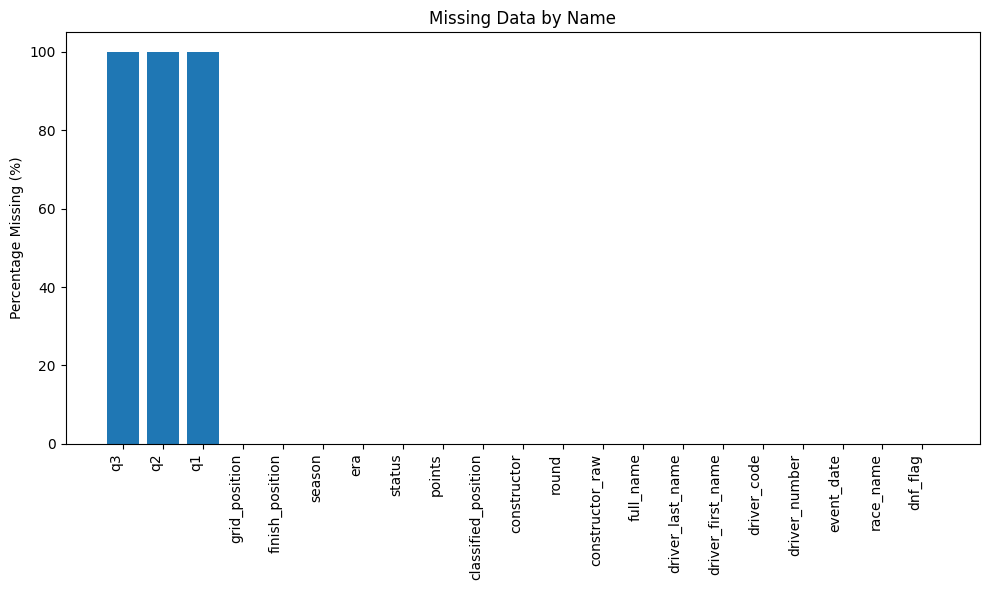

In [9]:
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
}).sort_values(by = 'Missing %', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(missing_df.index, missing_df['Missing %'])
plt.ylabel('Percentage Missing (%)')
plt.title('Missing Data by Name')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()

Looking at all the data I was missing, not a single entry that I wanted to collect was missing. The only data missing was the qualifying results, which I figured wouldn't do much for the training. After confirming all the races and respective data was present, it was time to begin cleaning it. 

------------------------------------------
Because the data was scraped as the race results for each individual driver, I had to transform the data into a "season-sized" database, to reflect a constructor's results. The goal is to predict constructor standings, so the race-by-race data had to be aggregated to reflect on a constructor's performance, not just an individual racer's. To achieve this, I add a few variables to such as "win_flag", "podium_flag", and "top10_flag" as metrics that were easily totaled to find the most winningest team. Afterwards, I grouped the data by season, followed by constructor, then era. Then, I normalized the podium and top ten finishes as rates as the amount of races per seasons varies, before I calculated the amount of points per constructor. Finally, I sorted by points in descending order.

![10x-speed-crash.gif](media/10x-speed-crash.gif "Oscar Piastri Baku Grand Prix Crash - 2025")

In [ ]:
df = pd.read_csv("f1_race_results_clean.csv")

numeric_cols = ["season", "round", "grid_position", "finish_position", "points"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

df["dnf_flag"] = df["dnf_flag"].astype(bool)

df["win_flag"] = df["finish_position"] == 1
df["podium_flag"] = df["finish_position"].isin([1, 2, 3])
df["top10_flag"] = df["finish_position"] <= 10

constructor_season = (
    df.groupby(["season", "constructor", "era"], as_index=False)
      .agg(
          races = ("round", "nunique"),
          total_points = ("points", "sum"),
          avg_grid_position = ("grid_position", "mean"),
          avg_finish_position = ("finish_position", "mean"),
          dnf_rate = ("dnf_flag", "mean"),
          wins = ("win_flag", "sum"),
          podiums = ("podium_flag", "sum"),
          top10_finishes = ("top10_flag", "sum")
      )
)

constructor_season["podium_rate"] = (
    constructor_season["podiums"] / (constructor_season["races"] * 2)
)

constructor_season["top10_rate"] = (
    constructor_season["top10_finishes"] / (constructor_season["races"] * 2)
)

constructor_season["final_rank"] = (
    constructor_season.groupby("season")["total_points"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

constructor_season = constructor_season.sort_values(
    ["season", "final_rank", "constructor"]
).reset_index(drop=True)

constructor_season.to_csv("constructor_season_table.csv", index=False)

print(constructor_season.shape)
print(constructor_season.head(20))

(169, 14)
    season   constructor                           era  races  total_points  \
0     2010      Red Bull  2010-2013_post_points_change     19         498.0   
1     2010       McLaren  2010-2013_post_points_change     19         454.0   
2     2010       Ferrari  2010-2013_post_points_change     19         396.0   
3     2010      Mercedes  2010-2013_post_points_change     19         214.0   
4     2010        Alpine  2010-2013_post_points_change     19         163.0   
5     2010      Williams  2010-2013_post_points_change     19          69.0   
6     2010  Aston Martin  2010-2013_post_points_change     19          68.0   
7     2010        Sauber  2010-2013_post_points_change     19          44.0   
8     2010            RB  2010-2013_post_points_change     19          13.0   
9     2010           HRT  2010-2013_post_points_change     19           0.0   
10    2010         Lotus  2010-2013_post_points_change     19           0.0   
11    2010      Marussia  2010-2013_post_p

------------------------------------------
Next, I shifted the necessary statistics forward by a season to create a lag. The model should only be using previous data, whatever is available, before it the season even begins to forecast future results. By doing so, it continuously carries historical performance forwards into future seasons.

As mentioned previously, there are two championships, the drivers' and constructors' championship. Each team has two drivers that compete for as many points as they can each race weekend, with the constructor point count being a total of both driver's points. That being said, the performance of a team's drivers is instrumental to a constructor's performance. After creating the lag columns, I implemented features to estimate the strength of each team's driver lineups before entering a new season. To estimate a team's strength, I used a driver's

- total points scored
- number of wins
- number of podium finishes
- average finishing positio
- race participation count

to create a weighted formula (points + 10 * wins + 5 * podiums) that emphasized race wins and podium finishes. Afterwards, I normalized the outcome, and then lagged and aggregated this outcome as well to maintain the structure.

![GettyImages-1230466.jpg](media/GettyImages-1230466.jpg "Transitional Era Car - Ayrton Senna, 1991 Sao Paulo Grand Prix")

In [9]:
constructor_season = constructor_season.sort_values(["constructor", "season"])

lag_cols = [
    "final_rank",
    "total_points",
    "avg_grid_position",
    "avg_finish_position",
    "dnf_rate",
    "wins",
    "podiums",
    "top10_finishes",
    "podium_rate",
    "top10_rate"
]

for col in lag_cols:
    constructor_season[f"prev_{col}"] = (
        constructor_season
        .groupby("constructor")[col]
        .shift(1)
    )

driver_season = (
    df.groupby(["season", "driver_code"], as_index=False)
    .agg(
        races=("round", "nunique"),
        points=("points", "sum"),
        avg_finish=("finish_position", "mean"),
        wins=("finish_position", lambda x: (x == 1).sum()),
        podiums=("finish_position", lambda x: x.isin([1, 2, 3]).sum()),
        dnf_rate=("dnf_flag", "mean")
    )
)

driver_season["raw_strength"] = (
    driver_season["points"]
    + 10 * driver_season["wins"]
    + 5 * driver_season["podiums"]
)

scaler = MinMaxScaler()
driver_season["driver_strength"] = scaler.fit_transform(
    driver_season[["raw_strength"]]
)

driver_season = driver_season.sort_values(["driver_code", "season"])
driver_season["prev_driver_strength"] = (
    driver_season.groupby("driver_code")["driver_strength"].shift(1)
)

driver_constructor = (
    df[["season", "driver_code", "constructor"]]
    .drop_duplicates()
)

driver_season = driver_season.merge(
    driver_constructor,
    on=["season", "driver_code"],
    how="left"
)

driver_team_strength = (
    driver_season.groupby(["season", "constructor"], as_index=False)
    .agg(
        prev_driver_strength_mean=("prev_driver_strength", "mean"),
        prev_driver_strength_max=("prev_driver_strength", "max")
    )
)

model_df = constructor_season.merge(
    driver_team_strength,
    on=["season", "constructor"],
    how="left"
)

model_df = model_df.dropna().reset_index(drop=True)

features = [
    "prev_total_points",
    "prev_avg_grid_position",
    "prev_avg_finish_position",
    "prev_dnf_rate",
    "prev_wins",
    "prev_podiums",
    "prev_top10_rate",
    "prev_final_rank",
    "prev_driver_strength_mean",
    "prev_driver_strength_max"
]

target = "final_rank"

model_df.to_csv("constructor_model_dataset_with_drivers.csv", index=False)

print(model_df.shape)
print(model_df.head())
print(model_df.columns.tolist())

(153, 26)
   season constructor                           era  races  total_points  \
0    2011      Alpine  2010-2013_post_points_change     19          73.0   
1    2012      Alpine  2010-2013_post_points_change     20         303.0   
2    2013      Alpine  2010-2013_post_points_change     19         315.0   
3    2014      Alpine        2014-2016_early_hybrid     19          10.0   
4    2015      Alpine        2014-2016_early_hybrid     19          78.0   

   avg_grid_position  avg_finish_position  dnf_rate  wins  podiums  ...  \
0          11.552632            12.657895  0.657895     0        2  ...   
1           7.775000             9.150000  0.250000     1       10  ...   
2           8.289474             8.526316  0.263158     1       14  ...   
3          16.315789            15.157895  0.842105     0        0  ...   
4          11.052632            12.526316  0.605263     0        1  ...   

   prev_avg_grid_position  prev_avg_finish_position  prev_dnf_rate  prev_wins  \
0

In [10]:
df = pd.read_csv("constructor_model_dataset_with_drivers.csv")
print(df.shape)
print(df.head())
print(df.columns.tolist())

(153, 26)
   season constructor                           era  races  total_points  \
0    2011      Alpine  2010-2013_post_points_change     19          73.0   
1    2012      Alpine  2010-2013_post_points_change     20         303.0   
2    2013      Alpine  2010-2013_post_points_change     19         315.0   
3    2014      Alpine        2014-2016_early_hybrid     19          10.0   
4    2015      Alpine        2014-2016_early_hybrid     19          78.0   

   avg_grid_position  avg_finish_position  dnf_rate  wins  podiums  ...  \
0          11.552632            12.657895  0.657895     0        2  ...   
1           7.775000             9.150000  0.250000     1       10  ...   
2           8.289474             8.526316  0.263158     1       14  ...   
3          16.315789            15.157895  0.842105     0        0  ...   
4          11.052632            12.526316  0.605263     0        1  ...   

   prev_avg_grid_position  prev_avg_finish_position  prev_dnf_rate  prev_wins  \
0

![charles-leclerc-leclerc.gif](media/charles-leclerc-leclerc.gif)

------------------------------------------
Now it's time to split the data, but I can't just seperate it into random training and testing sets, as the sport progresses, and so does the data. If the data were randomly split, I would entertain the possibility of testing previous seasons on a model trained with future seasons, which wouldn't make much sense. What I chose to do instead was train the model from the 2010 season up until the 2021 season, right before the second to last major regulation changes were put in place. That way, I could test the model on the, at the time, brand new 2022-2025 regulation cars. Every car is built on the foundation of decades of racing, even with the everchanging strict car regulations. Whenever constructors keep something that worked well, it is ingrained in the car's DNA, meaning it only makes sense for a chronological split. As seen later, the chronological split allows for the model to determine when a constructor makes a surge, as it favors momentum heavily.

In [11]:
train_df = df[df["season"] <= 2021].copy()
test_df  = df[df["season"] >= 2022].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print(train_df.columns.tolist())

Train shape: (113, 26)
Test shape: (40, 26)
['season', 'constructor', 'era', 'races', 'total_points', 'avg_grid_position', 'avg_finish_position', 'dnf_rate', 'wins', 'podiums', 'top10_finishes', 'podium_rate', 'top10_rate', 'final_rank', 'prev_final_rank', 'prev_total_points', 'prev_avg_grid_position', 'prev_avg_finish_position', 'prev_dnf_rate', 'prev_wins', 'prev_podiums', 'prev_top10_finishes', 'prev_podium_rate', 'prev_top10_rate', 'prev_driver_strength_mean', 'prev_driver_strength_max']


In [12]:
features = [
    "prev_total_points",
    "prev_avg_grid_position",
    "prev_avg_finish_position",
    "prev_dnf_rate",
    "prev_wins",
    "prev_podiums",
    "prev_top10_rate",
    "prev_final_rank",
    "prev_driver_strength_mean",
    "prev_driver_strength_max"
]

target = "final_rank"

X_train = train_df[features].copy()
y_train = train_df[target].copy()

X_test = test_df[features].copy()
y_test = test_df[target].copy()

------------------------------------------
Now that the data has been split, it's time to choose which model to train on. However, before we find which model is the best to train on, we have to standardize and scale using pipeline functions. Our data consists of multiple numerical metrics, such as points, positions, driver strength, etc, which could bring up issues if we don't do so. By standardizing, we ensure that no specific predictor dominates the model, especially because our numerical variables range differently. After a quick standardization, we finally begin working with models.

In [13]:
numeric_features = features

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

------------------------------------------
Next, I proposed a roster of models with the appropriate "default" parameters to see which one preforms the best. As opposed to tuning every model, which would be substantially more computation, time, and effort, I chose commonly used parameters for the respective models, such as five neightbors for a KNN model, or 1.0 alpha Ridge Regression. Right before testing the models, we introduce a five fold cross validation to get more stable estimates per each model.

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01, max_iter=10000),
    "Elastic Net": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    "K Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Support Vector Regression": SVR(C=1.0, epsilon=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=500, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

## Relationship Analysis
------------------------------------------
To explore the relationships between our predictors, we use a correlation matrix. We can see the strong relationships between several of our predictors, mostly between the performance-based metrics like previous points, podiums, and final rank. This is undoubtedly multicollinearity, where the features capture similar underlying information about team performance. This makes perfect sense, since some of these metrics were used to calculate predictors that were used in the training. Ridge Regression is particularly effective in this scenario, as it regularizes coefficients and stabilizes predictions.

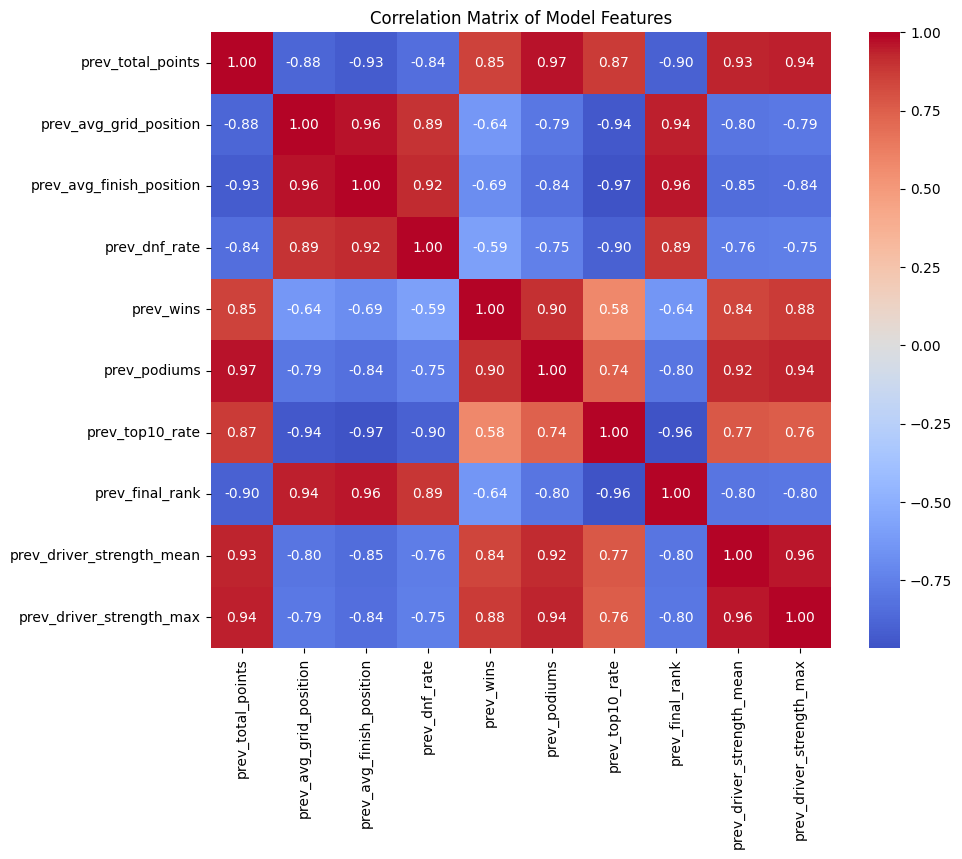

In [25]:
corr = model_df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0)
plt.title("Correlation Matrix of Model Features")
plt.show()

# Model Work
------------------------------------------
Many of the models performed really similarly, with barely any margin between some of the candidates. This tells us that, despite what model we use, there are clear patterns which help us predict where constructors will end up in the standings. Between the best and the worst model, there was only a difference of about 0.24 in RMSE, which means in terms of predicted standings, there is just under a quarter of position difference. However, Ridge Regression was the algorithim that performed the best, in that it had the lowest RMSE. This is likely because the features are highly correlated (e.g., points, podiums, and ranks), and Ridge stabilizes those predictors under multicollinearity.

In [16]:
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    results.append({
        "Model": name,
        "RMSE_mean": -cv_results["test_rmse"].mean(),
        "RMSE_sd": cv_results["test_rmse"].std(),
        "MAE_mean": -cv_results["test_mae"].mean(),
        "MAE_sd": cv_results["test_mae"].std()
    })

results_df = pd.DataFrame(results).sort_values("RMSE_mean")
print(results_df)

                       Model  RMSE_mean   RMSE_sd  MAE_mean    MAE_sd
1           Ridge Regression   1.659290  0.316981  1.280289  0.211675
4        K Nearest Neighbors   1.663292  0.326443  1.274783  0.230340
3                Elastic Net   1.670058  0.319622  1.290825  0.213285
0          Linear Regression   1.674698  0.322022  1.291809  0.199973
2           Lasso Regression   1.683703  0.321046  1.301114  0.214660
5  Support Vector Regression   1.696576  0.307211  1.309376  0.215143
7                Extra Trees   1.741842  0.327705  1.298545  0.250118
6              Random Forest   1.743788  0.330040  1.288031  0.255251
8          Gradient Boosting   1.897298  0.343204  1.402230  0.317214


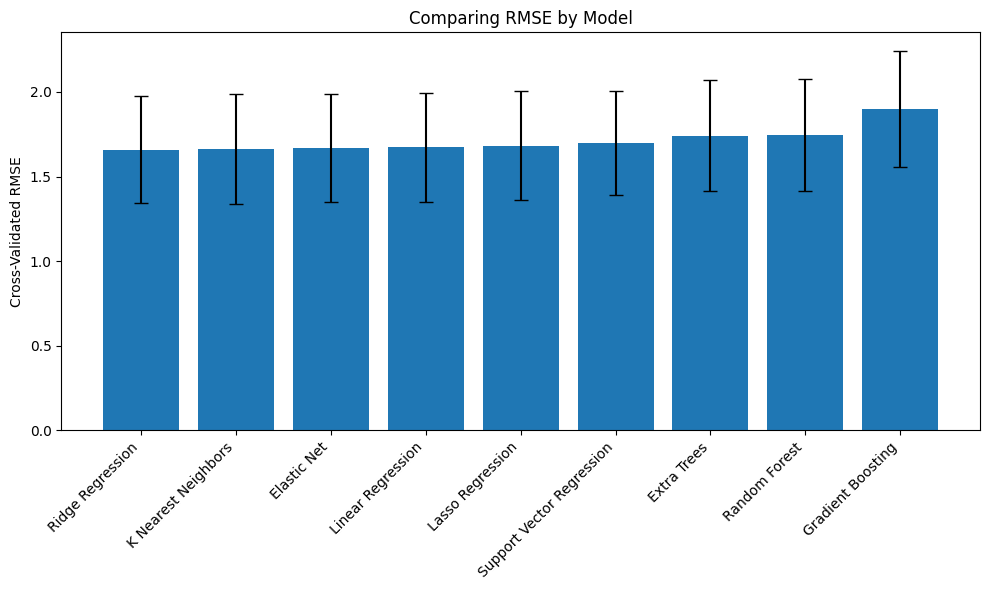

In [17]:
plot_df = results_df.sort_values("RMSE_mean", ascending=True)

plt.figure(figsize=(10, 6))
plt.bar(
    plot_df["Model"],
    plot_df["RMSE_mean"],
    yerr=plot_df["RMSE_sd"],
    capsize=5
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cross-Validated RMSE")
plt.title("Comparing RMSE by Model")
plt.tight_layout()
plt.show()

## Tuning Model
------------------------------------------
Now that I've figured Ridge Regression may be the best model, I ran through different alpha values, to find the best possible predictions. It might've been marginal, but the original mean CV RMSE of about 1.659290 dropped to about 1.618043 after a quick alpha adjustment.

In [18]:
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

best_model = grid.best_estimator_

Best params: {'model__alpha': 10}
Best CV RMSE: 1.6180427536367268


## Testing
------------------------------------------
Now that our Ridge Regression model is tuned, we run the testing data (2022-2025 ground-effect era race results), to test whether the model is a good fit. Unsurprisingly, the algorithim performed well, but actually even better on the testing data, than on the training data. Both our mean test RMSE and MAE ended up being lower than our mean training results, proving that the Ridge Regression model generalized well with unseen data. Additionally, it could also reflect that the test set follows similar structural patterns to the training data, rather than representing a fully independent distribution. This makes sense because, as mentioned earlier, Formula 1 cars are built on the foundation of learnings of previous eras and years.

In [19]:
X_test = test_df[features]
y_test = test_df[target]

preds = best_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("Test MAE:", mae)
print("Test RMSE:", rmse)

Test MAE: 1.2621109212966375
Test RMSE: 1.5236186401561733


Text(0.5, 1.0, 'Predicted vs Actual Constructor Rank')

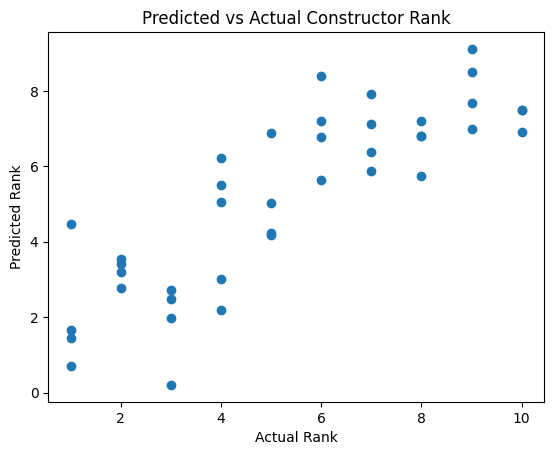

In [20]:
plt.scatter(y_test, preds)
plt.xlabel("Actual Rank")
plt.ylabel("Predicted Rank")
plt.title("Predicted vs Actual Constructor Rank")

Our points follow a diagonal, which indicates that the model is generally able to capture the relative ordering of constructors. However, there does seem to be some deviation due to the inability to capture the inherent unpredictability of race outcomes.

## Importance
------------------------------------------
Looking at the most important predictors in our model, we find that the model biases momentum heavy teams. In other words, if a team is going on a heater, and dominating the competition, the model will favor them in the standings. The most important predictor out of the bunch was the previous final rank, which is very representative of real life. If a team is preforming well, it's more unlikely to find them dropping far in the standings, unless their direct competitors are progressing much faster compared to them, which goes back to what I was saying about momentum. A team slows down in innovation and speed, while other teams catch up and grow in momentum.

In [ ]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42
)

importance_df = pd.DataFrame({
    "feature": features,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

print(importance_df)

                     feature  importance
7            prev_final_rank    0.090820
8  prev_driver_strength_mean    0.051091
9   prev_driver_strength_max    0.049207
2   prev_avg_finish_position    0.046206
1     prev_avg_grid_position    0.036998
5               prev_podiums    0.030659
3              prev_dnf_rate    0.021623
6            prev_top10_rate    0.012075
0          prev_total_points    0.004949
4                  prev_wins   -0.000967


# Monte Carlo Simulation
------------------------------------------
Now that we have our model, we create the necessary objects and functions to simulate what the next season of Formula 1's constructor standings could look like. We use what is most recently available, our "prev_..." variables, just like earlier, but incorporate randomness to simulate real life uncertainty. Race results are dependent on so many factors, not just whoever won the last race race. Whether it's car relibaility, driver performance, the weather, or even strategy, the outcomes rely on such complex situations, that it is best to simulate with a degree of randomness. To incorporate said randomness, I used residual resampling to resembles past model errors, but it still may not fully capture events such as big regulation shifts.

Fun Fact: "The Monte Carlo" method name originates from the the famous Monte-Carlo Casino located in Monaco, coincidentally, where one of the most famous F1 races takes place annually.  

![shutterstock_1407143231.jpg](media/shutterstock_1407143231.jpg "Monaco Grand Prix")

In [ ]:
sim_features = [
    "prev_total_points",
    "prev_avg_grid_position",
    "prev_avg_finish_position",
    "prev_dnf_rate",
    "prev_wins",
    "prev_podiums",
    "prev_top10_rate",
    "prev_final_rank",
    "prev_driver_strength_mean",
    "prev_driver_strength_max"
]

sim_2026 = df[df["season"] == 2025].copy()

sim_2026 = sim_2026[[
    "constructor",
    "total_points",
    "avg_grid_position",
    "avg_finish_position",
    "dnf_rate",
    "wins",
    "podiums",
    "top10_rate",
    "final_rank",
    "prev_driver_strength_mean",
    "prev_driver_strength_max"
]].copy()

sim_2026 = sim_2026.rename(columns={
    "total_points": "prev_total_points",
    "avg_grid_position": "prev_avg_grid_position",
    "avg_finish_position": "prev_avg_finish_position",
    "dnf_rate": "prev_dnf_rate",
    "wins": "prev_wins",
    "podiums": "prev_podiums",
    "top10_rate": "prev_top10_rate",
    "final_rank": "prev_final_rank"
})

print(sim_2026)

      constructor  prev_total_points  prev_avg_grid_position  \
14         Alpine               20.0               14.791667   
29   Aston Martin               80.0               12.872340   
46        Ferrari              360.0                7.395833   
57           Haas               73.0               14.604167   
77        McLaren              775.0                2.979167   
92       Mercedes              424.0                6.562500   
107            RB               88.0               10.562500   
122      Red Bull              410.0                8.666667   
137        Sauber               70.0               14.458333   
152      Williams              124.0               11.958333   

     prev_avg_finish_position  prev_dnf_rate  prev_wins  prev_podiums  \
14                  15.354167       0.604167          0             0   
29                  12.765957       0.382979          0             0   
46                   7.625000       0.145833          0             7   
57 

In [ ]:
base_preds = best_model.predict(sim_2026[sim_features])

sim_2026["pred_rank"] = base_preds
print(sim_2026[["constructor", "pred_rank"]].sort_values("pred_rank"))

      constructor  pred_rank
77        McLaren   1.647174
46        Ferrari   2.792685
92       Mercedes   2.943650
122      Red Bull   3.147774
152      Williams   4.909454
107            RB   6.326159
29   Aston Martin   6.549691
57           Haas   6.928175
137        Sauber   7.462356
14         Alpine   8.150516


In [ ]:
test_preds = best_model.predict(X_test)
residuals = y_test - test_preds

print("Residual mean:", residuals.mean())
print("Residual sd:", residuals.std())

Residual mean: 0.17637780748038268
Residual sd: 1.532654686938524


In [ ]:
def simulate_constructor_season(sim_df, model, feature_cols, residuals, n_sims=5000, random_state=42):
    rng = np.random.default_rng(random_state)
    constructors = sim_df["constructor"].tolist()
    base_pred = model.predict(sim_df[feature_cols])

    all_results = []

    residual_array = np.array(residuals)

    for sim in range(n_sims):
        sampled_noise = rng.choice(residual_array, size=len(sim_df), replace=True)
        simulated_score = base_pred + sampled_noise

        sim_round = pd.DataFrame({
            "constructor": constructors,
            "base_pred_rank": base_pred,
            "noise": sampled_noise,
            "simulated_score": simulated_score
        })

        sim_round["sim_rank"] = sim_round["simulated_score"].rank(method="first", ascending=True)
        sim_round["simulation"] = sim + 1

        all_results.append(sim_round[["simulation", "constructor", "simulated_score", "sim_rank"]])

    return pd.concat(all_results, ignore_index=True)

In [ ]:
sim_results = simulate_constructor_season(
    sim_df=sim_2026,
    model=best_model,
    feature_cols=sim_features,
    residuals=residuals,
    n_sims=10000,
    random_state=42
)

print(sim_results.head())
print(sim_results.shape)

   simulation   constructor  simulated_score  sim_rank
0           1        Alpine        11.239318      10.0
1           1  Aston Martin         9.347929       8.0
2           1       Ferrari         3.594135       3.0
3           1          Haas         5.864192       5.0
4           1       McLaren         0.583191       1.0
(100000, 4)


# Results
------------------------------------------
After thousands of Monte Carlo iterations, the results are summarized in a simple table, where we display in descending order, every team's mean_rank, median_rank, title_prob, top3_prob, and top5_prob. This is followed by a plot of each constructor's title odds, and estimated standings.

![pierre-gasly-alpine-a524.jpg](media/pierre-gasly-alpine-a524.jpg "Ground-Effect Era Car - Pierre Gasly, 2025")

In [ ]:
summary = (
    sim_results.groupby("constructor")
    .agg(
        mean_rank=("sim_rank", "mean"),
        median_rank=("sim_rank", "median"),
        title_prob=("sim_rank", lambda x: np.mean(x == 1)),
        top3_prob=("sim_rank", lambda x: np.mean(x <= 3)),
        top5_prob=("sim_rank", lambda x: np.mean(x <= 5))
    )
    .sort_values("mean_rank")
    .reset_index()
)

summary["title_prob"] = 100 * summary["title_prob"]
summary["top3_prob"] = 100 * summary["top3_prob"]
summary["top5_prob"] = 100 * summary["top5_prob"]

print(summary)

    constructor  mean_rank  median_rank  title_prob  top3_prob  top5_prob
0       McLaren     1.9318          2.0       48.47      88.52      99.57
1       Ferrari     2.8744          3.0       20.12      67.79      95.30
2      Mercedes     3.0366          3.0       16.53      63.99      94.20
3      Red Bull     3.2916          3.0       13.04      56.43      91.85
4      Williams     5.2408          5.0        1.68      16.10      57.90
5            RB     6.8727          7.0        0.10       3.46      22.48
6  Aston Martin     7.1826          7.0        0.04       1.96      17.39
7          Haas     7.5742          8.0        0.02       1.24      12.18
8        Sauber     8.1826          8.0        0.00       0.39       6.35
9        Alpine     8.8127          9.0        0.00       0.12       2.78


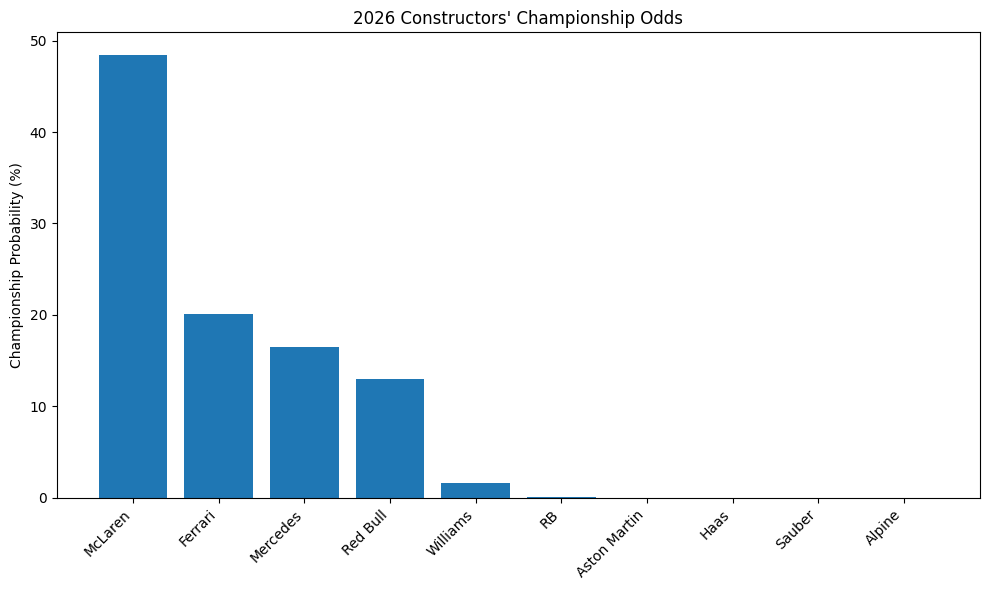

In [ ]:
plot_summary = summary.sort_values("title_prob", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(plot_summary["constructor"], plot_summary["title_prob"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Championship Probability (%)")
plt.title("2026 Constructors' Championship Odds")
plt.tight_layout()
plt.show()

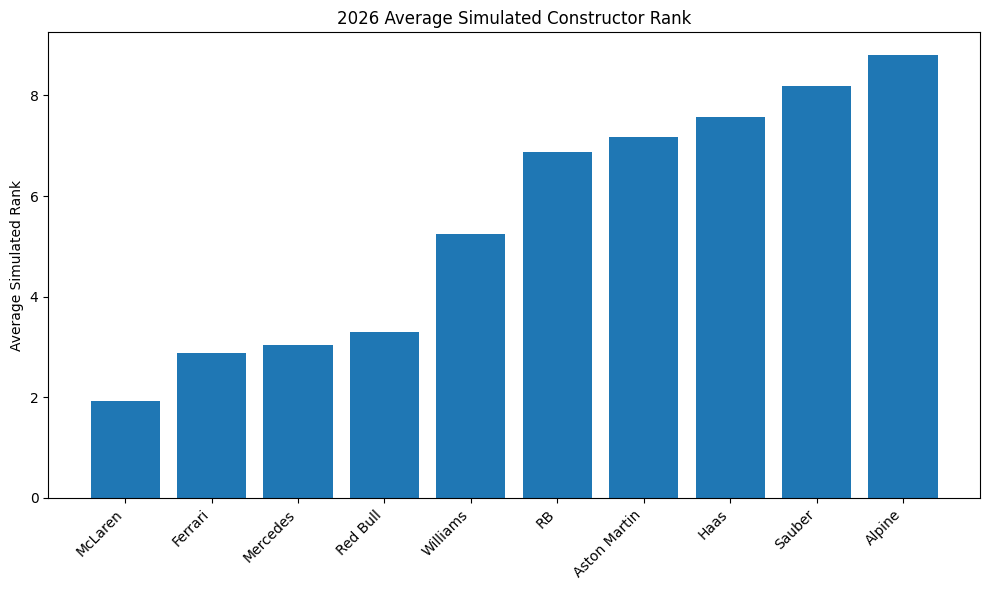

In [ ]:
plot_summary = summary.sort_values("mean_rank", ascending=True)

plt.figure(figsize=(10, 6))
plt.bar(plot_summary["constructor"], plot_summary["mean_rank"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Simulated Rank")
plt.title("2026 Average Simulated Constructor Rank")
plt.tight_layout()
plt.show()

In [ ]:
rank_dist = (
    sim_results.groupby(["constructor", "sim_rank"])
    .size()
    .reset_index(name="count")
)

rank_dist["probability"] = rank_dist.groupby("constructor")["count"].transform(lambda x: x / x.sum())

print(rank_dist.head())

  constructor  sim_rank  count  probability
0      Alpine       2.0      1       0.0001
1      Alpine       3.0     11       0.0011
2      Alpine       4.0     63       0.0063
3      Alpine       5.0    203       0.0203
4      Alpine       6.0    521       0.0521


In [ ]:
rank_prob = (
    sim_results.groupby(["constructor", "sim_rank"])
    .size()
    .reset_index(name="count")
)

rank_prob["probability"] = (
    rank_prob.groupby("constructor")["count"]
    .transform(lambda x: x / x.sum())
)

In [ ]:
heatmap_df = rank_prob.pivot(
    index="constructor",
    columns="sim_rank",
    values="probability"
).fillna(0)

print(heatmap_df)

sim_rank        1.0     2.0     3.0     4.0     5.0     6.0     7.0     8.0   \
constructor                                                                    
Alpine        0.0000  0.0001  0.0011  0.0063  0.0203  0.0521  0.1003  0.1498   
Aston Martin  0.0004  0.0044  0.0148  0.0453  0.1090  0.1752  0.2032  0.1921   
Ferrari       0.2012  0.2484  0.2283  0.1800  0.0951  0.0349  0.0102  0.0019   
Haas          0.0002  0.0022  0.0100  0.0276  0.0818  0.1457  0.1891  0.2092   
McLaren       0.4847  0.2501  0.1504  0.0827  0.0278  0.0042  0.0001  0.0000   
Mercedes      0.1653  0.2301  0.2445  0.1986  0.1035  0.0430  0.0124  0.0025   
RB            0.0010  0.0082  0.0254  0.0607  0.1295  0.1965  0.1984  0.1744   
Red Bull      0.1304  0.2093  0.2246  0.2235  0.1307  0.0553  0.0208  0.0047   
Sauber        0.0000  0.0006  0.0033  0.0132  0.0464  0.1036  0.1458  0.1891   
Williams      0.0168  0.0466  0.0976  0.1621  0.2559  0.1895  0.1197  0.0763   

sim_rank        9.0     10.0  
construc

In [ ]:
constructor_order = (
    sim_results.groupby("constructor")["sim_rank"]
    .mean()
    .sort_values()
    .index
)

heatmap_df = heatmap_df.loc[constructor_order]

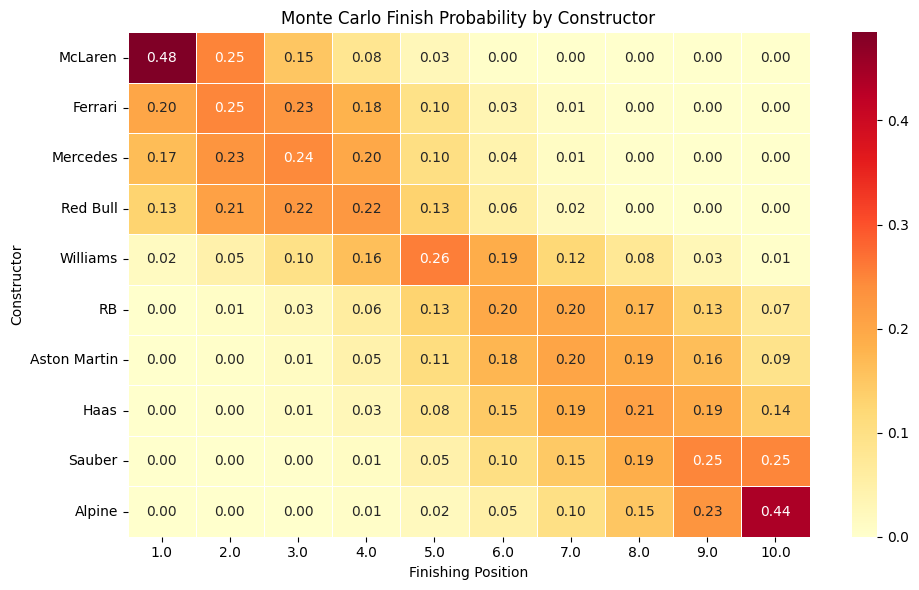

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_df,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Monte Carlo Finish Probability by Constructor")
plt.xlabel("Finishing Position")
plt.ylabel("Constructor")

plt.tight_layout()
plt.show()

plt.savefig("constructor_finish_heatmap.png", dpi=300)

![G2gB2CjWUAApyK2.jpeg](media/G2gB2CjWUAApyK2.jpeg "McLaren 2025 Constructor's Champions!")

### Conclusion
------------------------------------------
All in all, after the culmination of a quarter's worth of work, I've developed a machine learning model to predict F1's constructor standings. Sadly, because the new season and era of cars has just begun, the power rankings are still settling down, and it looks like the predictions aren't that accurate as of right now. My simulations say McLaren are set to dominate the new season, but with regulation changes, it looks like it Mercedes' game right now. Undoubtedly, if the new car regulations hadn't kicked in yet, McLaren would continue to dominate, but I guess we'll never know (the model might). Nevertheless, with only two races into the brand new season, we're seeing Mercedes absolutely dominate, Ferrari stay second, and Alpine out of all teams jump to the best of the rest, as in they went from dead-last to possibly top-4. Just looking at Alpine alone, the simulations predict that there's a 1% probability that the team even cracks fourth place this upcoming season, yet it looks good for them so far. 

To recap, by using historical race data, engineered performance features, and Monte Carlo methods, I was able to forecast the upcoming season's Constructor Championship standings and finishing probabilities. I did this by transforming single race-level results into constructor season-level metrics to create lagged features, which I then used to train my model. Across a range of candidate models, Ridge Regression achieved the best performance, although all models produced very similar results. Finally, with my Ridge Regression pipeline, we were able to run thousands of iterations of Monte Carlo simulation.

To wrap it all up, although we achieved relatively low training and testing RMSE and MAE, the most major limitation of the model is that assumes historical relationships will remain stable. In reality, Formula 1 performance is sometimes very volatile, but especially volatile during the start of a new era. In other words, the model doesn't capture sudden changes such as regulation changes, major car upgrade packages, new car designs, or driver swaps instantly. I've once heard Formula 1 described as a "science fair", where the amount of innovation and clever thinking going on in the paddock and factories is like no other. That innovation takes time though, and we are watching as teams scramble to figure everything out. The amount of unpredictibility and unreliability means that the predictors I used may not actually directly translate to future success. Sooner or later though, I predict that the model will adapt to the sudden changes once I introduce new race data, and begin predicting accurately again.

![f1.gif](media/f1.gif "Minor Inconvienence")

### Disclaimer
------------------------------------------
Throughout working on this project, I asked ChatGPT and Google (AI Mode) general questions, such as which libraries to use for the specific tasks that I was trying to complete. 

## Sources
------------------------------------------

1. https://en.wikipedia.org/wiki/History_of_Formula_One_regulations 
2. https://www.formula1.com/en/latest/article/the-key-regulation-changes-in-f1-history-and-the-teams-that-nailed-them.2iq8c5E6S1HOffT5PBLl6i
3. https://github.com/theOehrly/Fast-F1
4. https://docs.python.org/3/library/pathlib.html
5. https://docs.python.org/3/library/time.html
6. https://matplotlib.org/stable/index.html
7. https://pandas.pydata.org/docs/
8. https://numpy.org/doc/
9. https://scikit-learn.org/stable/user_guide.html
10. https://seaborn.pydata.org/
11. https://docs.jupyter.org/en/latest/use/using.html
12. https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet
13. https://stackoverflow.com/questions/11948245/markdown-to-create-pages-and-table-of-contents
14. ChatGPT
15. Google AI Search

### Media
------------------------------------------
1. https://www.formula1.com/en/latest/article/palmer-antonellis-brilliant-las-vegas-drive-came-at-the-perfect-time-for-the.5vIgBpNMwazihUt37Tdq3w
2. https://www.motorsportweek.com/2025/09/14/the-era-of-cars-max-verstappen-wants-f1-to-return-to/
3. https://tenor.com/view/car-gif-25812044
4. https://www.formula1.com/en/latest/article/i-was-there-for-sennas-emotional-home-victory-in-91.3UoP92VCfEOVjnXjQm7vme
5. https://tenor.com/view/10x-speed-crash-formula-1-gp-f1-gif-6793864404682226558
6. https://www.northropandjohnson.com/events/monaco-grand-prix
7. https://www.motorsport.com/f1/news/alpine-set-for-reality-check-with-new-f1-rules-in-2026/10689940/
8. https://x.com/F1/status/1974833097498640580/photo/1
9. https://tenor.com/view/f1-gif-8687200129990498193
10. https://tenor.com/view/charles-leclerc-leclerc-f1-f1-meme-f1-crash-gif-16417420332483004282